# Task 3 – Sound Data Collection and Processing

**Member:** Ajak Chol
**Date:** 2026-07-17

## Objective

This notebook covers Task 3 of the Multimodal Data Preprocessing assignment:

1. Load and display audio samples (waveforms + spectrograms) for all four group members
2. Apply at least two augmentations per sample (pitch shift, time stretch, background noise)
3. Extract audio features: MFCCs, spectral roll-off, spectral centroid, energy (RMS), zero-crossing rate
4. Save all features to `data/processed/audio_features.csv`

**Audio samples collected per member (2 per member):**

| File | Phrase |
|---|---|
| `memberN_approve.ogg` | *"Yes, approve"* |
| `memberN_confirm.ogg` | *"Confirm transaction"* |

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.fft import rfft, rfftfreq
from scipy.signal import get_window, resample, spectrogram

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT         = Path("..").resolve()
AUDIO_DIR    = ROOT / "data/raw/audio"
OUT_DIR      = ROOT / "data/processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_CSV = OUT_DIR / "audio_features.csv"

# ── DSP constants (must match src/voice_model.py) ────────────────────────────
TARGET_SR = 22050
N_MFCC    = 13
N_FFT     = 2048
HOP       = 512
N_MELS    = 26

MEMBERS = ["member1", "member2", "member3", "member4"]
MEMBER_COLOURS = {
    "member1": "#4C72B0",
    "member2": "#DD8452",
    "member3": "#55A868",
    "member4": "#C44E52",
}
PHRASE_LABELS = {
    "approve": '"Yes, approve"',
    "confirm": '"Confirm transaction"',
}

print("Setup complete.")
audio_files = sorted(AUDIO_DIR.glob("member*.ogg"))
print(f"Found {len(audio_files)} audio files:")
for f in audio_files:
    print(f"  {f.name}")

Setup complete.
Found 8 audio files:
  member1_approve.ogg
  member1_confirm.ogg
  member2_approve.ogg
  member2_confirm.ogg
  member3_approve.ogg
  member3_confirm.ogg
  member4_approve.ogg
  member4_confirm.ogg


## 2. Load Audio Samples

All files are converted to **mono float32** and resampled to **22 050 Hz** for a consistent pipeline regardless of the original recording device (members 1 & 4 recorded at 16 kHz; members 2 & 3 at 48 kHz).

In [2]:
def member_id(path: Path) -> str:
    m = re.match(r"(member\d+)", path.stem.replace("-", "_"), re.I)
    if not m:
        raise ValueError(f"Cannot parse member id from {path.name}")
    return m.group(1).lower()


def load_audio(path: Path, sr: int = TARGET_SR) -> tuple[np.ndarray, int]:
    """Load audio file → mono float32 at `sr` Hz."""
    y, file_sr = sf.read(path, always_2d=False)
    y = np.asarray(y, dtype=np.float32)
    if y.ndim > 1:
        y = y.mean(axis=1)
    if file_sr != sr and len(y) > 0:
        n_out = max(1, int(round(len(y) * sr / file_sr)))
        y = resample(y, n_out).astype(np.float32)
    return y, sr


audio_data: dict[str, tuple[np.ndarray, int]] = {}
print(f"{'File':35s} {'Orig SR':>8} {'Duration':>10} {'Samples':>10}")
print("-" * 67)
for path in audio_files:
    _, orig_sr = sf.read(path, always_2d=False)
    y, sr = load_audio(path)
    audio_data[path.stem] = (y, sr)
    print(f"  {path.name:33s} {orig_sr:>8} {len(y)/sr:>9.2f}s {len(y):>10}")

File                                 Orig SR   Duration    Samples
-------------------------------------------------------------------
  member1_approve.ogg                  16000      3.03s      66889
  member1_confirm.ogg                  16000      2.93s      64684
  member2_approve.ogg                  48000      2.43s      53659


  member2_confirm.ogg                  48000      2.35s      51895
  member3_approve.ogg                  48000      3.06s      67473
  member3_confirm.ogg                  48000      3.74s      82467
  member4_approve.ogg                  16000      2.62s      57859
  member4_confirm.ogg                  16000      4.35s      95962


## 3. Waveform Visualisation

Waveforms plot amplitude over time and confirm each sample is non-silent and captures the full phrase.

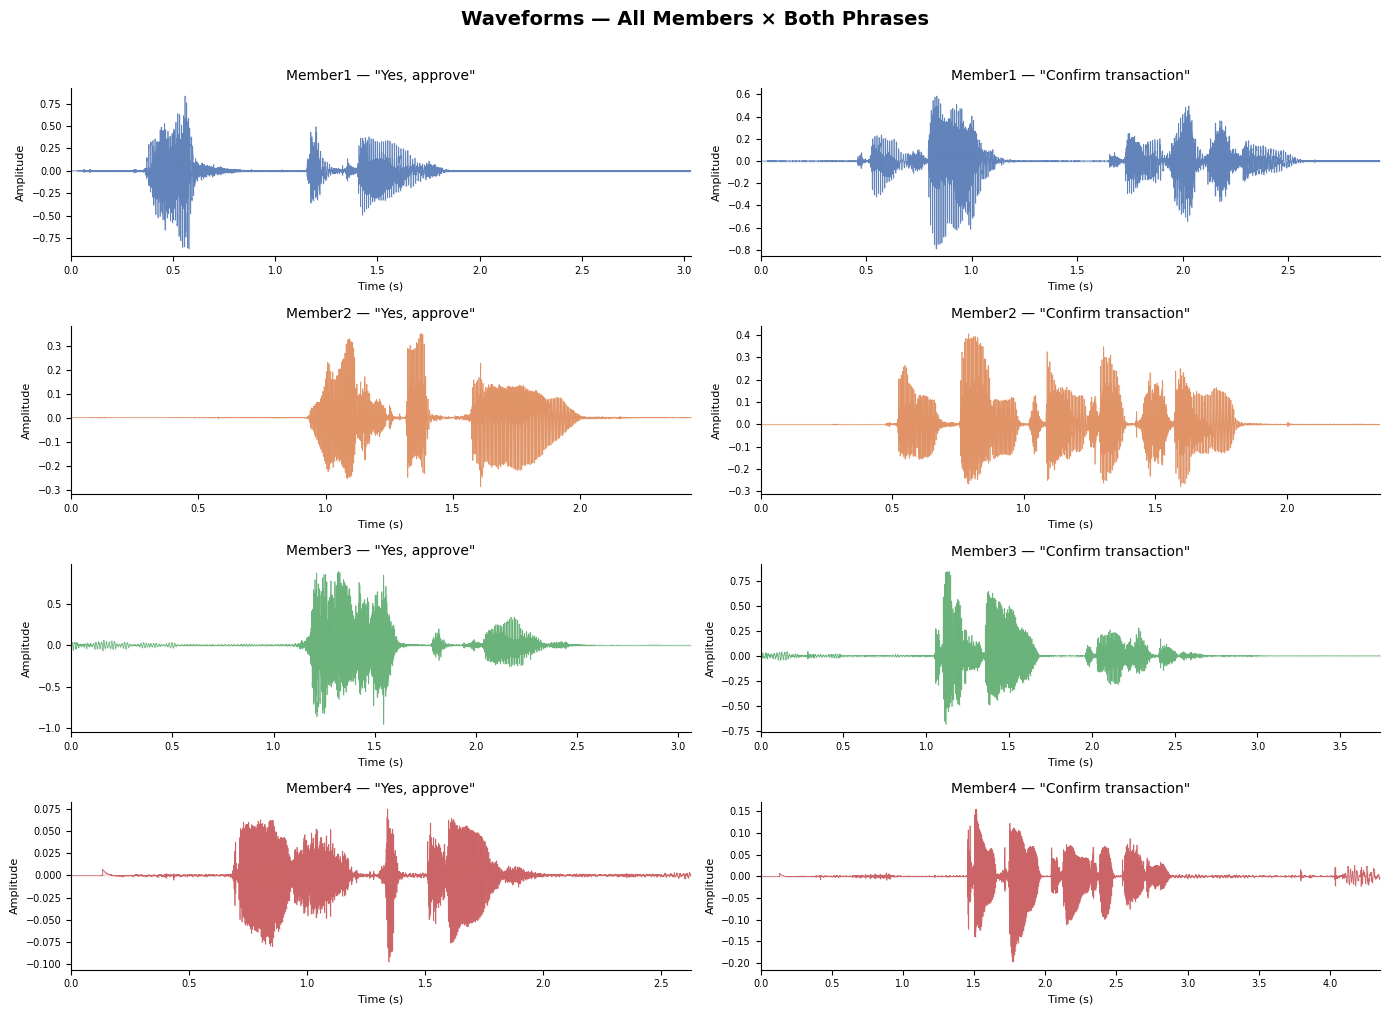

Saved: waveforms.png


In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle("Waveforms — All Members × Both Phrases", fontsize=14, fontweight="bold", y=1.01)

for row, mem in enumerate(MEMBERS):
    for col, phrase in enumerate(["approve", "confirm"]):
        key = f"{mem}_{phrase}"
        ax  = axes[row][col]
        if key not in audio_data:
            ax.set_visible(False)
            continue
        y, sr = audio_data[key]
        t = np.linspace(0, len(y) / sr, len(y))
        c = MEMBER_COLOURS[mem]
        ax.plot(t, y, color=c, linewidth=0.5, alpha=0.85)
        ax.fill_between(t, y, alpha=0.12, color=c)
        ax.set_title(f"{mem.capitalize()} — {PHRASE_LABELS[phrase]}", fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=8)
        ax.set_ylabel("Amplitude", fontsize=8)
        ax.set_xlim(0, t[-1])
        ax.tick_params(labelsize=7)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "waveforms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: waveforms.png")

## 4. Spectrogram Visualisation

Mel spectrograms show how frequency content evolves over time. Voiced speech appears as horizontal harmonic bands; silence is dark. The mel scale compresses high frequencies to match human auditory perception.

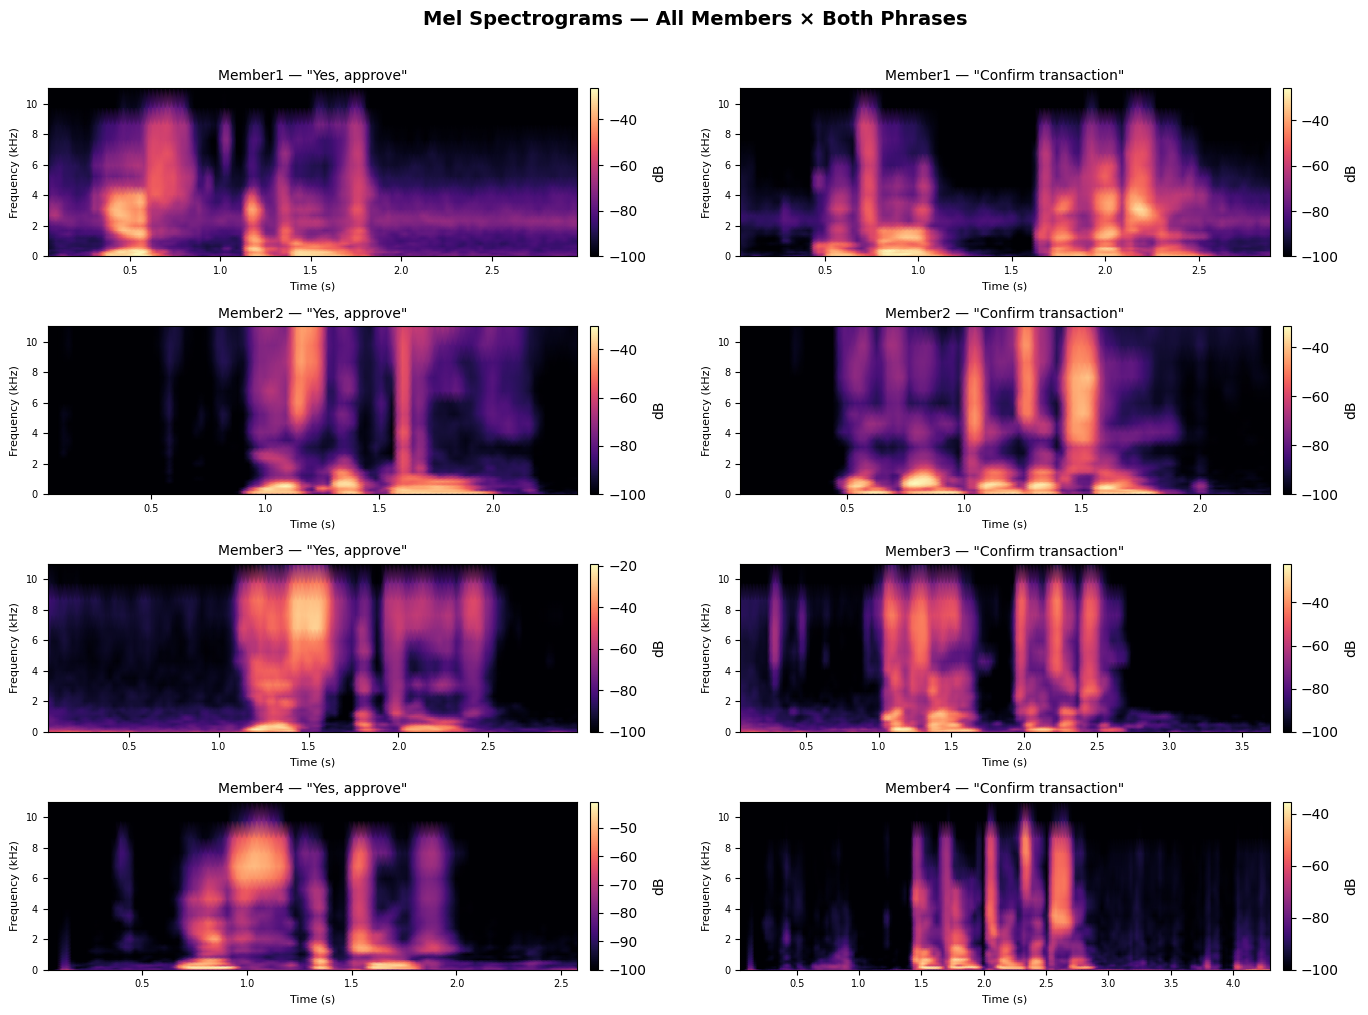

Saved: spectrograms.png


In [4]:
def mel_spectrogram_db(y, sr, n_fft=N_FFT, hop=HOP, n_mels=N_MELS):
    """Compute mel-scaled log-power spectrogram using scipy only."""
    f, t, Sxx = spectrogram(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop, window="hann")

    def hz2mel(h): return 2595.0 * np.log10(1.0 + np.asarray(h) / 700.0)
    def mel2hz(m): return 700.0 * (10.0 ** (np.asarray(m) / 2595.0) - 1.0)

    mels      = np.linspace(hz2mel(0), hz2mel(sr / 2), n_mels + 2)
    hz_pts    = mel2hz(mels)
    bins      = np.floor((n_fft + 1) * hz_pts / sr).astype(int).clip(0, len(f) - 1)
    fb        = np.zeros((n_mels, len(f)), dtype=np.float32)
    for i in range(n_mels):
        lo, ctr, hi = bins[i], bins[i + 1], bins[i + 2]
        if ctr > lo: fb[i, lo:ctr] = (np.arange(lo, ctr) - lo) / (ctr - lo)
        if hi > ctr: fb[i, ctr:hi] = (hi - np.arange(ctr, hi)) / (hi - ctr)

    mel_power = fb @ Sxx
    mel_db    = 10 * np.log10(np.maximum(mel_power, 1e-10))
    mel_freqs = mel2hz(np.linspace(hz2mel(0), hz2mel(sr / 2), n_mels))
    return t, mel_freqs, mel_db


fig, axes = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle("Mel Spectrograms — All Members × Both Phrases", fontsize=14, fontweight="bold", y=1.01)

for row, mem in enumerate(MEMBERS):
    for col, phrase in enumerate(["approve", "confirm"]):
        key = f"{mem}_{phrase}"
        ax  = axes[row][col]
        if key not in audio_data:
            ax.set_visible(False)
            continue
        y, sr = audio_data[key]
        t, mel_f, mel_db = mel_spectrogram_db(y, sr)
        im = ax.pcolormesh(t, mel_f / 1000, mel_db, shading="gouraud", cmap="magma")
        ax.set_title(f"{mem.capitalize()} — {PHRASE_LABELS[phrase]}", fontsize=10)
        ax.set_xlabel("Time (s)", fontsize=8)
        ax.set_ylabel("Frequency (kHz)", fontsize=8)
        ax.tick_params(labelsize=7)
        plt.colorbar(im, ax=ax, label="dB", pad=0.02)

plt.tight_layout()
plt.savefig(OUT_DIR / "spectrograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: spectrograms.png")

## 5. Augmentations

Data augmentation expands the dataset and makes the voice model robust to natural variation. Five augmentations are applied per sample:

| # | Augmentation | Technique | Purpose |
|---|---|---|---|
| 1 | **Time stretch (fast)** | Resample to 1.15× speed | Simulates hurried speech |
| 2 | **Time stretch (slow)** | Resample to 0.85× speed | Simulates deliberate speech |
| 3 | **Pitch shift up** | Resample shorter → restore length | Higher-pitched voice |
| 4 | **Pitch shift down** | Resample longer → restore length | Lower-pitched voice |
| 5 | **Background noise** | Additive Gaussian (σ = 0.005) | Real-world recording conditions |

In [5]:
def apply_augmentations(y: np.ndarray, sr: int = TARGET_SR) -> list[tuple[str, np.ndarray]]:
    rng      = np.random.default_rng(42)
    variants = [("original", y.copy())]

    if len(y) > 10:
        variants.append(("stretch_fast", resample(y, int(len(y) / 1.15)).astype(np.float32)))
        variants.append(("stretch_slow", resample(y, int(len(y) / 0.85)).astype(np.float32)))

        up   = resample(resample(y, int(len(y) * 0.9)).astype(np.float32), len(y)).astype(np.float32)
        down = resample(resample(y, int(len(y) * 1.1)).astype(np.float32), len(y)).astype(np.float32)
        variants.append(("pitch_up",   up))
        variants.append(("pitch_down", down))

    noise = rng.normal(0, 0.005, size=y.shape).astype(np.float32)
    variants.append(("noise", y + noise))
    return variants


# Demonstrate on member4_approve (real recording)
demo_y, demo_sr = audio_data["member4_approve"]
demo_augs       = apply_augmentations(demo_y, demo_sr)
print(f"Augmentations for member4_approve (real recording, dur={len(demo_y)/demo_sr:.2f}s):")
print(f"  {'Name':15s}  {'Samples':>8}  {'Duration':>10}")
print("  " + "-" * 38)
for name, sig in demo_augs:
    print(f"  {name:15s}  {len(sig):>8}  {len(sig)/demo_sr:>9.2f}s")

Augmentations for member4_approve (real recording, dur=2.62s):
  Name              Samples    Duration
  --------------------------------------
  original            57859       2.62s
  stretch_fast        50312       2.28s
  stretch_slow        68069       3.09s
  pitch_up            57859       2.62s
  pitch_down          57859       2.62s
  noise               57859       2.62s


### 5.1 Waveform Comparison — Member 4 "Yes, approve" (Real Recording)

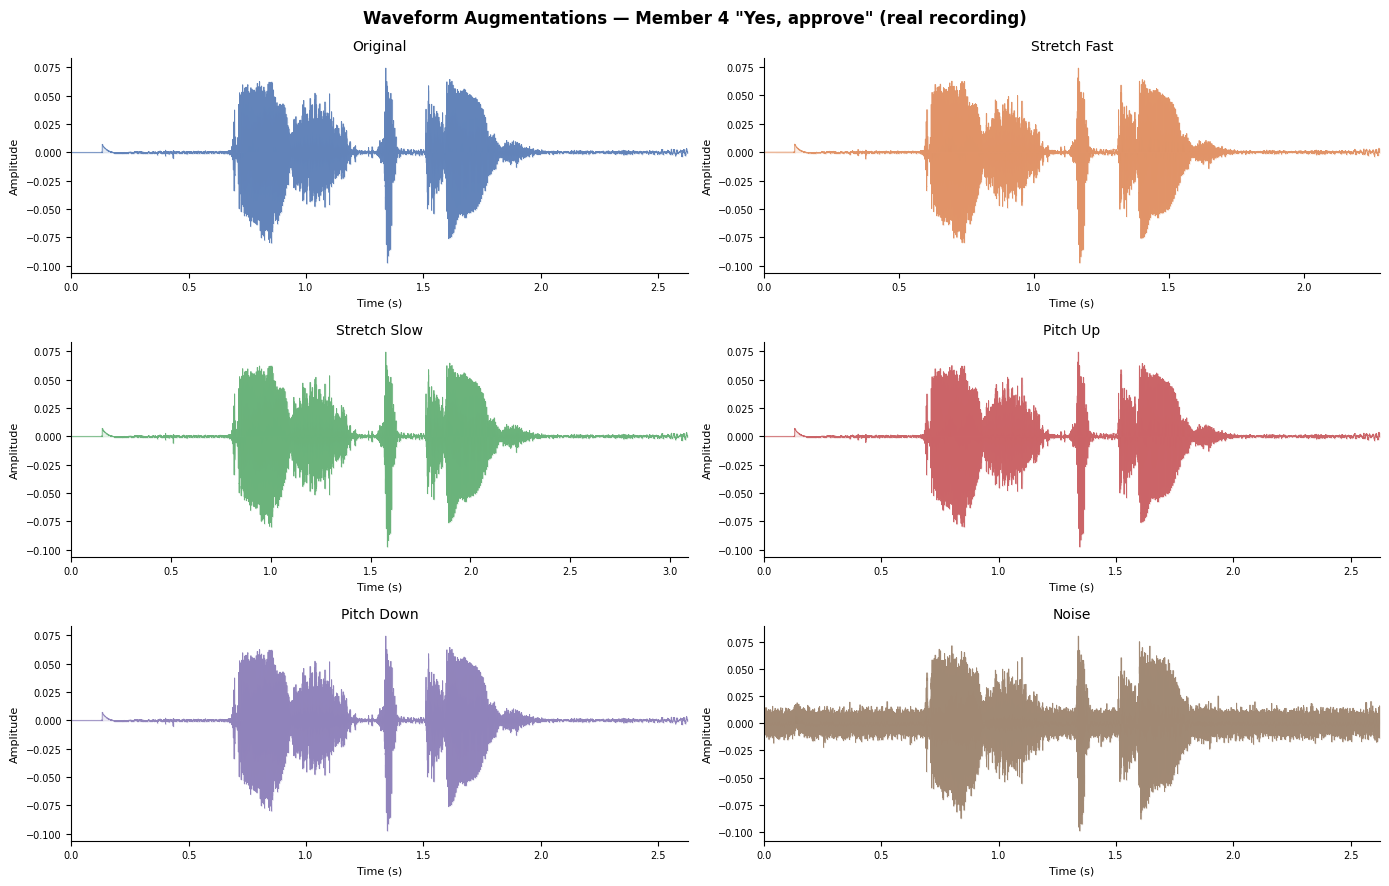

Saved: augmentation_demo.png


In [6]:
AUG_COLOURS = {
    "original":     "#4C72B0",
    "stretch_fast": "#DD8452",
    "stretch_slow": "#55A868",
    "pitch_up":     "#C44E52",
    "pitch_down":   "#8172B2",
    "noise":        "#937860",
}

fig, axes = plt.subplots(3, 2, figsize=(14, 9))
fig.suptitle('Waveform Augmentations — Member 4 "Yes, approve" (real recording)',
             fontsize=12, fontweight="bold")

for ax, (name, sig) in zip(axes.flat, demo_augs):
    t = np.linspace(0, len(sig) / demo_sr, len(sig))
    c = AUG_COLOURS.get(name, "steelblue")
    ax.plot(t, sig, color=c, linewidth=0.6, alpha=0.85)
    ax.fill_between(t, sig, alpha=0.13, color=c)
    ax.set_title(name.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("Amplitude", fontsize=8)
    ax.set_xlim(0, t[-1])
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "augmentation_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: augmentation_demo.png")

### 5.2 Spectrogram Comparison — Member 4 "Yes, approve"

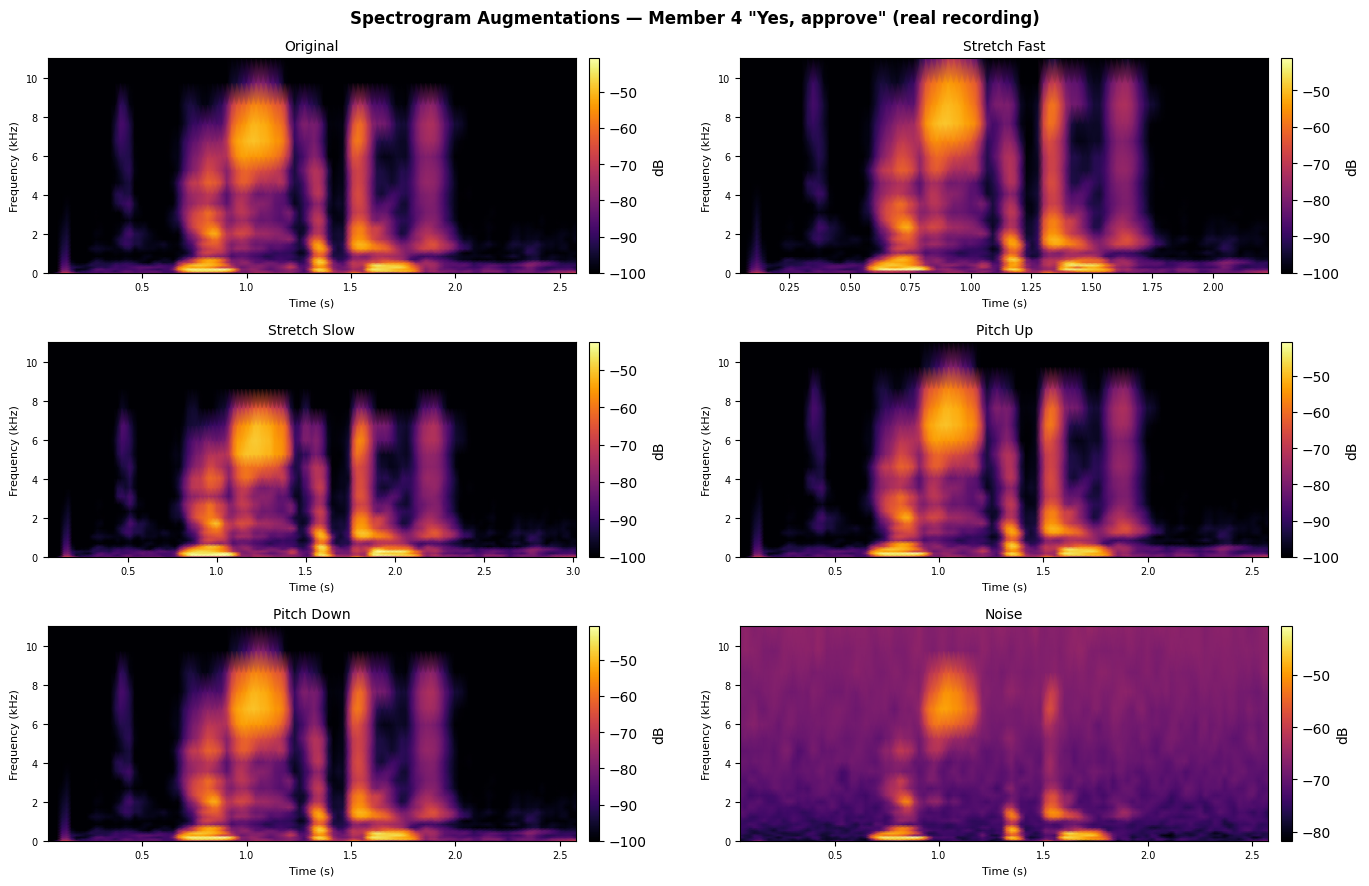

Saved: augmentation_spectrograms.png


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
fig.suptitle('Spectrogram Augmentations — Member 4 "Yes, approve" (real recording)',
             fontsize=12, fontweight="bold")

for ax, (name, sig) in zip(axes.flat, demo_augs):
    t, mel_f, mel_db = mel_spectrogram_db(sig, demo_sr)
    im = ax.pcolormesh(t, mel_f / 1000, mel_db, shading="gouraud", cmap="inferno")
    ax.set_title(name.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("Frequency (kHz)", fontsize=8)
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, label="dB", pad=0.02)

plt.tight_layout()
plt.savefig(OUT_DIR / "augmentation_spectrograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: augmentation_spectrograms.png")

## 6. Feature Extraction

The same feature set used by `src/voice_model.py` is implemented here for transparency. All computation uses only `numpy` and `scipy`.

| Feature group | Columns | Description |
|---|---|---|
| **MFCCs** | `mfcc_mean_0` – `mfcc_std_12` (26 cols) | Mel-frequency cepstral coefficients — primary speaker-identity descriptor |
| **Spectral roll-off** | `spectral_rolloff_mean`, `_std` | Frequency below which 85% of spectral energy lies |
| **Spectral centroid** | `spectral_centroid_mean` | Perceptual brightness of the voice |
| **Energy (RMS)** | `energy_mean`, `energy_std` | Loudness and its variation across frames |
| **Zero-crossing rate** | `zcr_mean` | Noisiness / fricative content |
| **Duration** | `duration_sec` | Total phrase length in seconds |

In [8]:
def frame_signal(y, frame_length=N_FFT, hop=HOP):
    if len(y) < frame_length:
        y = np.pad(y, (0, frame_length - len(y)))
    n_frames = 1 + (len(y) - frame_length) // hop
    frames   = np.stack([y[i*hop : i*hop+frame_length] for i in range(n_frames)])
    window   = get_window("hann", frame_length, fftbins=True).astype(np.float32)
    return frames * window


def _hz2mel(h): return 2595.0 * np.log10(1.0 + np.asarray(h) / 700.0)
def _mel2hz(m): return 700.0 * (10.0 ** (np.asarray(m) / 2595.0) - 1.0)


def mel_filterbank(sr, n_fft=N_FFT, n_mels=N_MELS):
    freqs    = rfftfreq(n_fft, d=1.0 / sr)
    mels     = np.linspace(_hz2mel(0), _hz2mel(sr / 2), n_mels + 2)
    hz_pts   = _mel2hz(mels)
    bins     = np.floor((n_fft + 1) * hz_pts / sr).astype(int)
    fb       = np.zeros((n_mels, len(freqs)), dtype=np.float32)
    for i in range(n_mels):
        lo, ctr, hi = bins[i], bins[i+1], bins[i+2]
        if ctr == lo: ctr += 1
        if hi == ctr: hi  += 1
        for j in range(lo,  ctr):
            if 0 <= j < fb.shape[1]: fb[i, j] = (j - lo)  / (ctr - lo)
        for j in range(ctr, hi):
            if 0 <= j < fb.shape[1]: fb[i, j] = (hi - j)  / (hi - ctr)
    return fb


def compute_mfcc(y, sr=TARGET_SR, n_mfcc=N_MFCC):
    frames   = frame_signal(y)
    spectra  = np.abs(rfft(frames, axis=1)) ** 2
    fb       = mel_filterbank(sr)
    mel      = np.maximum(spectra @ fb.T, 1e-10)
    log_mel  = np.log(mel)
    n        = log_mel.shape[1]
    k        = np.arange(n_mfcc)[:, None]
    dct      = np.cos(np.pi * (np.arange(n) + 0.5) * k / n)
    return (log_mel @ dct.T).T   # (n_mfcc, n_frames)


def extract_features(y, sr=TARGET_SR):
    if len(y) == 0:
        y = np.zeros(sr // 10, dtype=np.float32)

    mfcc      = compute_mfcc(y, sr)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std  = mfcc.std(axis=1)

    frames   = frame_signal(y)
    spectra  = np.abs(rfft(frames, axis=1))
    freqs    = rfftfreq(N_FFT, d=1.0 / sr)
    power    = spectra ** 2
    cumsum   = np.cumsum(power, axis=1)
    total    = cumsum[:, -1][:, None] + 1e-10
    rolloff  = freqs[np.argmax(cumsum >= 0.85 * total, axis=1)]
    centroid = (spectra * freqs).sum(axis=1) / (spectra.sum(axis=1) + 1e-10)
    rms      = np.sqrt((frames ** 2).mean(axis=1))
    zcr      = ((frames[:, 1:] * frames[:, :-1]) < 0).mean(axis=1)

    feats = {}
    for i, (m, s) in enumerate(zip(mfcc_mean, mfcc_std)):
        feats[f"mfcc_mean_{i}"] = float(m)
        feats[f"mfcc_std_{i}"]  = float(s)
    feats["spectral_rolloff_mean"]  = float(rolloff.mean())
    feats["spectral_rolloff_std"]   = float(rolloff.std())
    feats["spectral_centroid_mean"] = float(centroid.mean())
    feats["energy_mean"]            = float(rms.mean())
    feats["energy_std"]             = float(rms.std())
    feats["zcr_mean"]               = float(zcr.mean())
    feats["duration_sec"]           = float(len(y) / sr)
    return feats


# Sanity check
sample_feats = extract_features(*audio_data["member4_approve"])
print(f"Feature count: {len(sample_feats)}")
print("\nAll extracted features:")
for k, v in sample_feats.items():
    print(f"  {k:30s} = {v:10.5f}")

Feature count: 33

All extracted features:
  mfcc_mean_0                    = -134.34629
  mfcc_std_0                     =   86.67112
  mfcc_mean_1                    =   41.55750
  mfcc_std_1                     =   22.38263
  mfcc_mean_2                    =  -14.37188
  mfcc_std_2                     =   11.38694
  mfcc_mean_3                    =   27.43092
  mfcc_std_3                     =    7.87544
  mfcc_mean_4                    =  -17.69016
  mfcc_std_4                     =    7.62936
  mfcc_mean_5                    =   23.08233
  mfcc_std_5                     =    8.97250
  mfcc_mean_6                    =  -23.75219
  mfcc_std_6                     =    9.12101
  mfcc_mean_7                    =   12.90887
  mfcc_std_7                     =    5.43213
  mfcc_mean_8                    =  -18.59154
  mfcc_std_8                     =    6.40864
  mfcc_mean_9                    =   13.86228
  mfcc_std_9                     =    4.41787
  mfcc_mean_10                   =  -

## 7. Build and Save `audio_features.csv`

Features are extracted for every **(member × phrase × augmentation)** combination — 48 rows total.

In [9]:
rows = []
for path in sorted(AUDIO_DIR.glob("member*.ogg")):
    mem = member_id(path)
    y, sr = load_audio(path)
    for aug_name, aug_y in apply_augmentations(y, sr):
        feats = extract_features(aug_y, sr)
        feats["member_id"]    = mem
        feats["source_file"]  = path.name
        feats["augmentation"] = aug_name
        rows.append(feats)

df = pd.DataFrame(rows)
df.to_csv(FEATURES_CSV, index=False)

print(f"Saved → {FEATURES_CSV}")
print(f"Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nRows per member × augmentation:")
print(df.groupby(["member_id", "augmentation"]).size().unstack(fill_value=0))
df.head(4)

Saved → /home/claude/multimodel-data-preprocessing-main/data/processed/audio_features.csv
Shape : 48 rows × 36 columns

Rows per member × augmentation:
augmentation  noise  original  pitch_down  pitch_up  stretch_fast  \
member_id                                                           
member1           2         2           2         2             2   
member2           2         2           2         2             2   
member3           2         2           2         2             2   
member4           2         2           2         2             2   

augmentation  stretch_slow  
member_id                   
member1                  2  
member2                  2  
member3                  2  
member4                  2  


,mfcc_mean_0,mfcc_std_0,mfcc_mean_1,mfcc_std_1,mfcc_mean_2,mfcc_std_2,mfcc_mean_3,mfcc_std_3,mfcc_mean_4,mfcc_std_4,...,spectral_rolloff_mean,spectral_rolloff_std,spectral_centroid_mean,energy_mean,energy_std,zcr_mean,duration_sec,member_id,source_file,augmentation
0,-58.167707,66.981923,50.660861,24.473119,-31.863945,12.470858,36.169480,9.533358,-12.430637,6.890661,...,2462.923690,1547.579692,2108.566334,0.025757,0.044301,0.163639,3.033515,member1,member1_approve.ogg,original
1,-32.594818,70.332303,27.242980,24.357828,-10.409163,13.768136,20.037847,9.832720,1.204830,4.218777,...,2800.784579,1808.266665,2423.199931,0.026059,0.044241,0.186042,2.637823,member1,member1_approve.ogg,stretch_fast
2,-97.763621,61.316848,86.189170,23.938985,-61.199009,11.091898,54.570555,12.295076,-25.427332,10.048948,...,2088.505371,1289.894269,1787.381581,0.025463,0.044354,0.139964,3.568798,member1,member1_approve.ogg,stretch_slow
3,-58.062620,67.024054,50.555961,24.437612,-31.759626,12.457124,36.066115,9.532669,-12.328614,6.884749,...,2462.923690,1547.579692,2108.580891,0.025757,0.044301,0.163639,3.033515,member1,member1_approve.ogg,pitch_up


## 8. Feature Distribution Analysis

Comparing key features across members (original samples only) confirms the MFCC-based representation is discriminative enough to separate speakers.

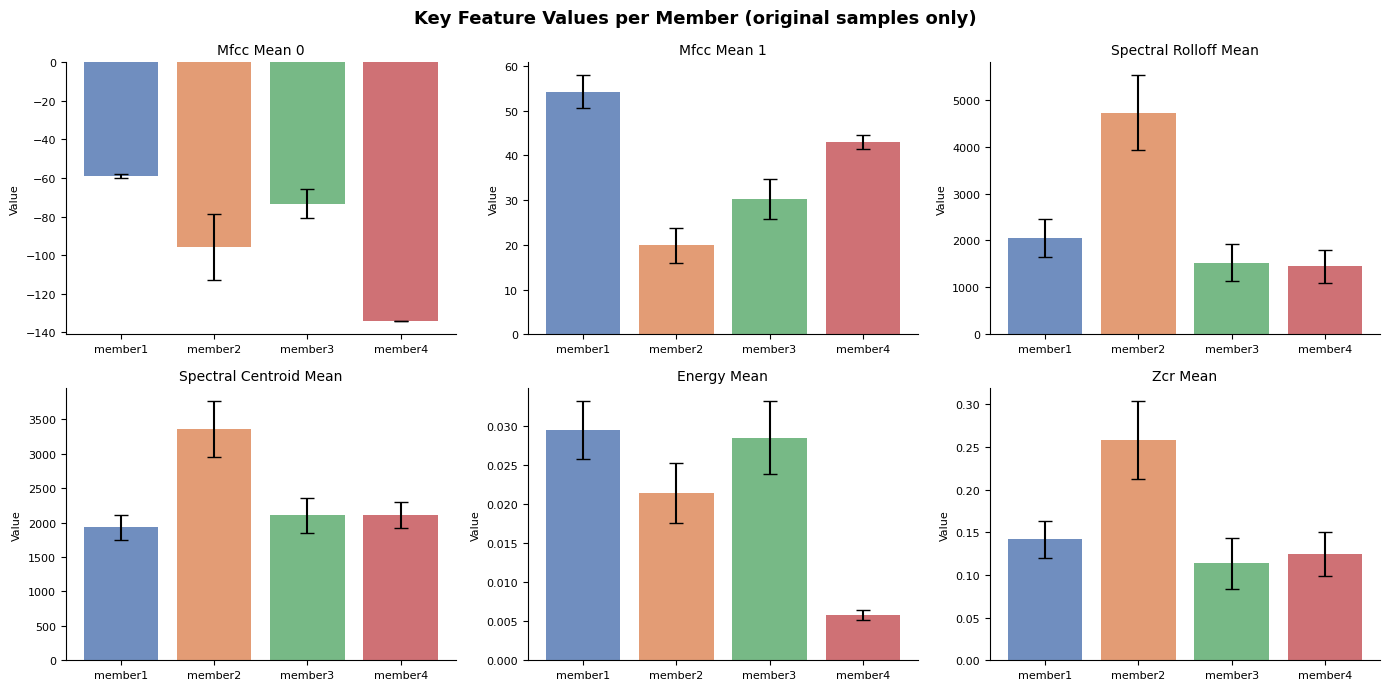

Saved: feature_distributions.png


In [10]:
orig = df[df["augmentation"] == "original"].copy()

key_features = [
    "mfcc_mean_0", "mfcc_mean_1",
    "spectral_rolloff_mean", "spectral_centroid_mean",
    "energy_mean", "zcr_mean",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Key Feature Values per Member (original samples only)",
             fontsize=13, fontweight="bold")

for ax, feat in zip(axes.flat, key_features):
    vals  = [orig[orig["member_id"] == m][feat].values for m in MEMBERS]
    means = [v.mean() if len(v) else 0 for v in vals]
    stds  = [v.std()  if len(v) else 0 for v in vals]
    bars  = ax.bar(MEMBERS, means,
                   color=[MEMBER_COLOURS[m] for m in MEMBERS], alpha=0.8)
    ax.errorbar(MEMBERS, means, yerr=stds,
                fmt="none", color="black", capsize=5, linewidth=1.5)
    ax.set_title(feat.replace("_", " ").title(), fontsize=10)
    ax.set_ylabel("Value", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / "feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: feature_distributions.png")

## 9. MFCC Fingerprint Heatmap

Each member's mean MFCC vector (averaged over both phrases, original only) forms a unique spectral fingerprint. Visible differences between rows confirm the features are speaker-discriminative.

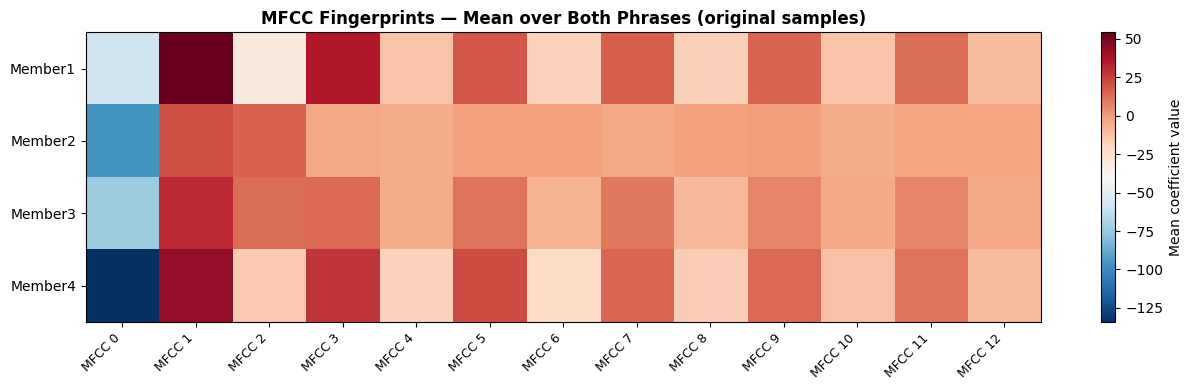

Saved: mfcc_heatmap.png


In [11]:
mfcc_cols    = [f"mfcc_mean_{i}" for i in range(N_MFCC)]
heatmap_data = orig.groupby("member_id")[mfcc_cols].mean().loc[MEMBERS]

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="RdBu_r")
ax.set_xticks(range(N_MFCC))
ax.set_xticklabels([f"MFCC {i}" for i in range(N_MFCC)], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(MEMBERS)))
ax.set_yticklabels([m.capitalize() for m in MEMBERS], fontsize=10)
plt.colorbar(im, ax=ax, label="Mean coefficient value")
ax.set_title("MFCC Fingerprints — Mean over Both Phrases (original samples)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "mfcc_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: mfcc_heatmap.png")

## 10. Summary

| Item | Value |
|---|---|
| Members | 4 (member1 – member4) |
| Phrases per member | 2 (*"Yes, approve"*, *"Confirm transaction"*) |
| Augmentation variants per sample | 6 (original + stretch fast/slow + pitch up/down + noise) |
| Total rows in `audio_features.csv` | **48** |
| Acoustic feature columns | 33 |
| Total CSV columns | 36 (33 features + `member_id`, `source_file`, `augmentation`) |
| Output file | `data/processed/audio_features.csv` |

In [12]:
print("=" * 55)
print("Task 3 complete.")
print(f"  audio_features.csv : {df.shape[0]} rows × {df.shape[1]} cols")
print(f"  Plots saved to     : data/processed/")
print("=" * 55)
df.describe().T[["mean", "std", "min", "max"]].round(4)

Task 3 complete.
  audio_features.csv : 48 rows × 36 cols
  Plots saved to     : data/processed/


,mean,std,min,max
mfcc_mean_0,-74.6435,50.6311,-169.3269,31.8169
mfcc_std_0,81.7413,25.0287,18.4422,113.1175
mfcc_mean_1,32.0001,22.6886,-7.4499,92.4590
mfcc_std_1,24.3186,4.4348,12.5731,31.3347
mfcc_mean_2,-3.6553,21.5087,-61.1990,23.3268
mfcc_std_2,11.7373,2.0468,6.0277,16.6089
mfcc_mean_3,16.0865,17.2889,-7.1357,54.5706
mfcc_std_3,9.4607,2.1190,3.5348,13.4423
mfcc_mean_4,-8.4571,9.3051,-32.9650,4.0013
mfcc_std_4,8.0004,1.9160,3.0207,11.7564
